# Project

In [42]:
import pandas as pd
#from thefuzz import process
#from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# For imputation
#from sklearn.experimental import enable_iterative_imputer  # noqa
#from sklearn.impute import IterativeImputer

from scipy import stats
from sklearn.feature_selection import VarianceThreshold, RFE
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier #, ExtraTreesRegressor
from sklearn.tree import DecisionTreeRegressor

import numpy as np
from sklearn.base import BaseEstimator, clone
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from typing import Dict

from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.neighbors import KNeighborsRegressor

from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor

import random
from copy import deepcopy
import time

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN

In [43]:
import sys
import os

# Add the current directory to sys.path so we can import from Functions
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

# Import Preprocessing functions
from Functions.preprocessing import (
    simple_processing, 
    remove_price_outliers, 
    fit_transform_encoding, 
    decode, 
    minimal_features
)

# Import Imputation functions
from Functions.imputation import (
    mode_imputation, 
    fit_imputer, 
    apply_imputer, 
    fit_price_imputer, 
    apply_price_imputer
)

from Functions.Engineering import *

from Functions.Train import *

from Functions.Selection import *
# Import

In [44]:
train_df = pd.read_csv("https://raw.githubusercontent.com/LiberoBiagi/ML_Nova_IMS_25-26/refs/heads/main/data/train.csv")

In [45]:
train_df = train_df.set_index("carID")
train_df = train_df.drop(columns=["paintQuality%"])

In [46]:
#train_df.head()

### Making sure that the model prices are not typos

In [47]:
"""
#df_cleaned = simple_processing(train_df)
#df_cleaned = df_cleaned[df_cleaned["model"].notna()]
#df_price_model = df_cleaned[["Brand","model", "price"]].copy()

# Get the list of unique models
models = df_price_model['model'].unique()

# Loop through each model and create a boxplot
#for model in models:
sns.catplot(data=df_price_model, y='price', col='model', kind='box', col_wrap=4, height=3, sharey=False)
plt.show()"""

'\n#df_cleaned = simple_processing(train_df)\n#df_cleaned = df_cleaned[df_cleaned["model"].notna()]\n#df_price_model = df_cleaned[["Brand","model", "price"]].copy()\n\n# Get the list of unique models\nmodels = df_price_model[\'model\'].unique()\n\n# Loop through each model and create a boxplot\n#for model in models:\nsns.catplot(data=df_price_model, y=\'price\', col=\'model\', kind=\'box\', col_wrap=4, height=3, sharey=False)\nplt.show()'

## Data cleaning

## Workflow for Train and Validation Sets

TODO: Explanation

#### Encoding

In [48]:
# Fix typos and small numeric cleanup
df = simple_processing(train_df)

# Remove extreme price outliers
df = remove_price_outliers(df)

# Encode cateogrical columns and replace the str with int columns. Return fitted encoders for decoding at the end
df_encoded, encoders = fit_transform_encoding(df)

#### Creating the stratification column

In [49]:
# Create Categorical price column with 0 < 1 < 2 for the price
df_encoded["price_cat"] = pd.qcut(df_encoded["price"], 3, labels=False)

# Combine the 10 unique brand values (1-9 & NA) with the 3 unique price category values (0-2)
stratify_col = df_encoded["Brand_transformed"].astype(str) + "_" + df_encoded["price_cat"].astype(str)

#### Imputation and decoding

In [50]:
# Train validation split
train_split, validation_split = train_test_split(df_encoded, test_size=0.2, random_state=69, stratify=stratify_col)
# train_split, validation_split = train_test_split(df_encoded, test_size=0.2, random_state=42)

# Drop price_cat column from both splits as it would introduce data leakage
train_split = train_split.drop("price_cat", axis=1)
validation_split = validation_split.drop("price_cat", axis=1)

train_split = mode_imputation(train_split)
validation_split = mode_imputation(validation_split)

# Train imputer on train (data leakage risk thus only train on train_split)
imputer = fit_imputer(train_split)

# Apply trained imputer to both datasplits
imputed_train = apply_imputer(train_split, imputer)
imputed_validation = apply_imputer(validation_split, imputer)

# Impute the missing price values created by removing extrem outliers
# In our step to remove extrem price outliers we introduced missing values in the price column. However, in our normal imputer, which we also use for imputing the test 
# Dataset we can not fix these values as this would cause the imputer to not work on the test subset, with no price feature. 
# Thus we create a seperate price imputer to fix the missing values in the testing and validation sets. This imputer is trained on train and applied to validation
# Fit price imputer
price_imputer = fit_price_imputer(imputed_train)
# Apply price imputer
imputed_train = apply_price_imputer(imputed_train, price_imputer)
imputed_validation = apply_price_imputer(imputed_validation, price_imputer)

# Decode encoded columns using the fitted encoders
train_processed = decode(imputed_train, encoders)
validation_processed = decode(imputed_validation, encoders)

c:\Users\liber\anaconda3\envs\ML_env\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


## Workflow for Cleaning Testing Dataset

We use all the information available from the training data sets (train and validation splits) to fit imputers and preprocess the testing dataset. This should create a scenario as close to real world deployment as possible, where we use our existing data to process new data entries.

In [51]:
test_df = pd.read_csv("https://raw.githubusercontent.com/LiberoBiagi/ML_Nova_IMS_25-26/refs/heads/main/data/test.csv")

In [52]:
test_df = test_df.set_index("carID")
test_df = test_df.drop(columns=["paintQuality%"])

### Simple pre Imputation processing of Test data

In [53]:
test = simple_processing(test_df)

test_df_encoded, test_encoders = fit_transform_encoding(test)

### Fit the full testing imputer

In [54]:
# Preprocess the full training dataframe from scratch
df = simple_processing(train_df)
df = remove_price_outliers(df)
df_encoded, encoders = fit_transform_encoding(df)
train_df_mode_imputed = mode_imputation(df_encoded)

# Train a full imputer on the all available training data
full_training_imputer = fit_imputer(train_df_mode_imputed)

c:\Users\liber\anaconda3\envs\ML_env\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


### Apply the full imputer to the testing data

In [55]:
#df_encoded_no_price = test_df_imputed.drop(["price", "price_cat"], axis=1)

# Apply imputer trained on testing data
test_df_imputed = apply_imputer(test_df_encoded, full_training_imputer)

test_processed = decode(test_df_imputed, test_encoders)

In [56]:
train_val_models = set(pd.concat([train_processed, validation_processed])["model"].unique())
test_models = set(test_processed["model"].unique())

missing_models = train_val_models - test_models


In [57]:
list(missing_models)


['200',
 'caddy maxi',
 'streetka',
 'kadjar',
 '220',
 'ranger',
 's8',
 'escort',
 '230',
 'verso-s',
 'accent',
 'a2',
 'getz',
 'urban cruiser']

## Checking our data

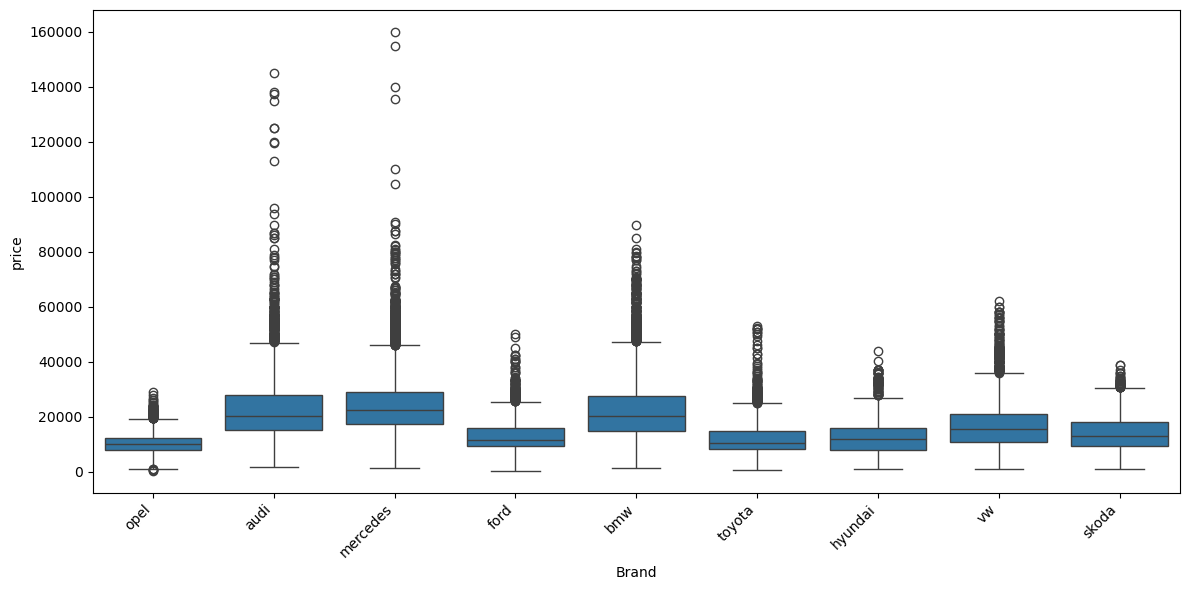

In [58]:
# Boxlpots for every brand.
plt.figure(figsize=(12, 6))
sns.boxplot(data=train_processed, x='Brand', y='price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# There seem to be extreme values in our data for different brands, which might not seem to be outliers when observing our dataset as a whole. 
# We can assume that not only for brands do these types of outliers exist, but also for models. 

In [59]:
def remove_outliers_by_group(df, group_col, value_col, iqr_multiplier=1.5):
    """Remove outliers within each group based on the IQR method."""
    
    def filter_outliers(group):
        Q1 = group[value_col].quantile(0.25)
        Q3 = group[value_col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - iqr_multiplier * IQR
        upper_bound = Q3 + iqr_multiplier * IQR
        
        return group[(group[value_col] >= lower_bound) & (group[value_col] <= upper_bound)]
    
    return df.groupby(group_col, group_keys=False).apply(filter_outliers)

# Remove price outliers for each model separately
#train_cleaned = remove_outliers_by_group(train_processed, group_col='model', value_col='price')

# Display statistics
#print(f"Original shape: {train_processed.shape}")
#print(f"After removing outliers: {train_cleaned.shape}")
#print(f"Number of outliers removed: {train_processed.shape[0] - train_cleaned.shape[0]}")
#print(f"Percentage of data removed: {((train_processed.shape[0] - train_cleaned.shape[0]) / train_processed.shape[0] * 100):.2f}%")

#train_processed = train_cleaned

# It works well but we lose a lot of data. (2.57% if we take the iqr*1.5)

# If this is too much of a loss, we can try a different iqr multiplier, 2x for example.

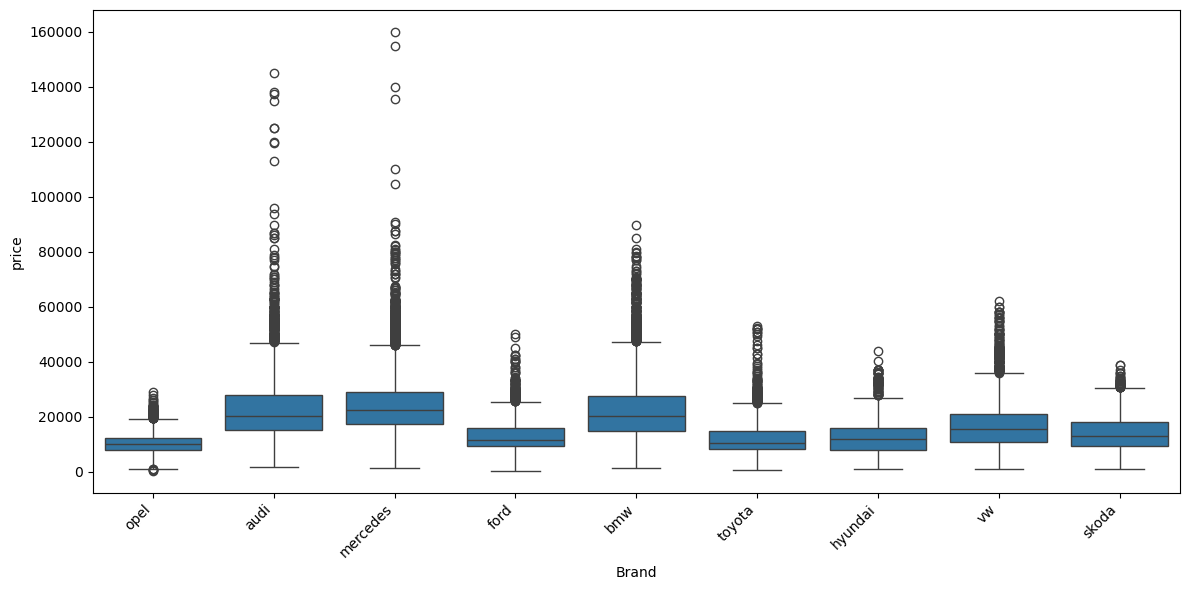

In [60]:
# Visualize boxplot after outlier removal
plt.figure(figsize=(12, 6))
sns.boxplot(data=train_processed, x='Brand', y='price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [61]:
# Checking the audi models with the highest prices
brand_name = 'audi'
brand_avg = train_processed[train_processed['Brand'] == brand_name].groupby('model')['price'].mean().sort_values(ascending=False)
print(brand_avg)
print("\nThe audi cars descending by price:\n")

audi_cars = train_processed[train_processed['Brand'] == 'audi'][['model', 'price']].sort_values('price', ascending=False)
print(audi_cars)

# After cleaning the outliers and looking at the boxplots for all brands audi was seemingly the only brand with large extreme values,
# however these prices all belong to the r8 model which is known to be expensive.

# The cleaning seemed to be effective.

model
r8             93981.578947
puma           89750.000000
q8             58339.969697
rs6            53705.797070
mokka x        52742.500000
                   ...     
s5             13496.500000
ampera         11551.000000
grand c-max    11500.000000
a2             10495.636364
kadjar         10000.000000
Name: price, Length: 107, dtype: float64

The audi cars descending by price:

      model     price
10483    r8  145000.0
1082     r8  137995.0
42802    r8  137500.0
16774    r8  135000.0
43634    r8  125000.0
...     ...       ...
56952    a4    2675.0
8788     a6    2495.0
46747    a6    2490.0
1203     a2    2490.0
56299    a4    1699.0

[5970 rows x 2 columns]


## Feature Engineering

In [62]:
train_processed.index = train_processed.index.astype(int)
validation_processed.index = validation_processed.index.astype(int)

In [63]:
X_train = train_processed
X_val = validation_processed

In [64]:
X_train = minimal_features(X_train)
X_val = minimal_features(X_val)

In [65]:
model_mean_price = X_train.groupby('model')['price'].mean()

X_train['model_mean_price'] = X_train['model'].map(model_mean_price)
X_val['model_mean_price']   = X_val['model'].map(model_mean_price)

model_std_price = X_train.groupby("model")["price"].std()

model_std_price = model_std_price.fillna(0) 

X_train['model_std_price'] = X_train['model'].map(model_std_price)

X_val['model_std_price'] = X_val['model'].map(model_std_price).fillna(0)

model_median_price = X_train.groupby("model")["price"].median()
X_train['model_median_price'] = X_train['model'].map(model_median_price)
X_val['model_median_price']   = X_val['model'].map(model_median_price)




In [66]:
y_train = X_train['price']
y_val = X_val['price']

In [67]:
X_train, X_val = smoothed_mean_encoding(X_train, X_val, y_train, 'model', m=20)
X_train, X_val = smoothed_mean_encoding(X_train, X_val, y_train, 'Brand', m=50)

In [68]:
X_train = X_train.drop(columns=['price', "model"])

X_val = X_val.drop(columns=['price', "model"])


In [69]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60778 entries, 0 to 60777
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   mileage                    60778 non-null  int32  
 1   tax                        60778 non-null  int32  
 2   mpg                        60778 non-null  float64
 3   engineSize                 60778 non-null  float64
 4   previousOwners             60778 non-null  int32  
 5   stated_no_damage           60778 non-null  float64
 6   Brand                      60778 non-null  object 
 7   transmission               60778 non-null  object 
 8   fuelType                   60778 non-null  object 
 9   age                        60778 non-null  int32  
 10  mileage_per_year           60778 non-null  float64
 11  efficiency_ratio           60778 non-null  float64
 12  age_mileage                60778 non-null  float64
 13  age_squared                60778 non-null  int32  


In [70]:
X_val.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15195 entries, 0 to 15194
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   mileage                    15195 non-null  int32  
 1   tax                        15195 non-null  int32  
 2   mpg                        15195 non-null  float64
 3   engineSize                 15195 non-null  float64
 4   previousOwners             15195 non-null  int32  
 5   stated_no_damage           15195 non-null  float64
 6   Brand                      15195 non-null  object 
 7   transmission               15195 non-null  object 
 8   fuelType                   15195 non-null  object 
 9   age                        15195 non-null  int32  
 10  mileage_per_year           15195 non-null  float64
 11  efficiency_ratio           15195 non-null  float64
 12  age_mileage                15195 non-null  float64
 13  age_squared                15195 non-null  int32  


In [71]:
y_train.info()

<class 'pandas.core.series.Series'>
Index: 60778 entries, 0 to 60777
Series name: price
Non-Null Count  Dtype  
--------------  -----  
60778 non-null  float64
dtypes: float64(1)
memory usage: 712.2 KB


In [72]:
y_val.info()

<class 'pandas.core.series.Series'>
Index: 15195 entries, 0 to 15194
Series name: price
Non-Null Count  Dtype  
--------------  -----  
15195 non-null  float64
dtypes: float64(1)
memory usage: 178.1 KB


## Test of the models on the full dataset

### Linear Regression

In [73]:
LR = LinearRegression()
trainer = BrandModelTrainer(LR)

# fit
trainer.fit(X_train, y_train)

# performance overall
trainer.evaluate_train(X_train, y_train)
trainer.evaluate(X_val, y_val)

# performance per brand
trainer.evaluate_train_by_brand(X_train, y_train)
trainer.evaluate_by_brand(X_val, y_val)

Training models for 9 brands...

  ✓ opel done.
  ✓ audi done.
  ✓ mercedes done.
  ✓ ford done.
  ✓ bmw done.
  ✓ toyota done.
  ✓ hyundai done.
  ✓ vw done.
  ✓ skoda done.

Training Set Performance (Overall):
  RMSE: 3291.46
  MAE:  2088.52
  R²:   0.8823

Validation Set Performance (Overall):
  RMSE: 3337.18
  MAE:  2108.77
  R²:   0.8772

Training Performance per Brand:
   Brand     N        RMSE         MAE       R²
    opel  7640 1651.116223 1209.232471 0.782223
    ford 13111 2005.100601 1430.578469 0.822380
   skoda  3504 2084.544207 1482.251934 0.884089
 hyundai  2721 2273.941410 1599.482474 0.856187
  toyota  3775 2401.812146 1468.466430 0.849712
      vw  8479 3119.389685 2089.996780 0.836485
     bmw  6037 4265.784655 2910.226096 0.858842
    audi  5970 4313.125331 2815.293605 0.863613
mercedes  9541 4914.296755 3328.187009 0.784840

Validation Performance per Brand:
   Brand    N        RMSE         MAE       R²
    opel 1908 1768.012353 1250.370109 0.754613
   skoda  882

,Brand,N,RMSE,MAE,R²
7,opel,1908,1768.012353,1250.370109,0.754613
8,skoda,882,2056.019860,1479.099854,0.889054
5,hyundai,686,2092.794940,1557.681731,0.872182
1,ford,3278,2152.370585,1430.504508,0.795724
3,toyota,940,2720.428844,1597.452893,0.836312
0,vw,2125,3017.033824,2101.222294,0.849330
6,audi,1490,4177.221506,2810.901969,0.863587
2,bmw,1505,4525.173491,2983.204330,0.840517
4,mercedes,2381,4945.014063,3338.927329,0.776602


### Decision Tree

In [74]:
Tree = DecisionTreeRegressor(criterion="absolute_error")
trainer = BrandModelTrainer(Tree)

# fit
trainer.fit(X_train, y_train)

# performance overall
trainer.evaluate_train(X_train, y_train)
trainer.evaluate(X_val, y_val)

# performance per brand
trainer.evaluate_train_by_brand(X_train, y_train)
trainer.evaluate_by_brand(X_val, y_val)        # Performance VALID

Training models for 9 brands...

  ✓ opel done.
  ✓ audi done.
  ✓ mercedes done.
  ✓ ford done.
  ✓ bmw done.
  ✓ toyota done.
  ✓ hyundai done.
  ✓ vw done.
  ✓ skoda done.

Training Set Performance (Overall):
  RMSE: 105.80
  MAE:  5.97
  R²:   0.9999

Validation Set Performance (Overall):
  RMSE: 2791.49
  MAE:  1637.29
  R²:   0.9141

Training Performance per Brand:
   Brand     N       RMSE       MAE       R²
  toyota  3775  36.503141  1.572185 0.999965
    ford 13111  63.048775  3.537564 0.999824
      vw  8479  72.103869  5.183866 0.999913
   skoda  3504  81.232575  3.905251 0.999824
    audi  5970  91.279664  4.120268 0.999939
    opel  7640 119.273002 10.624084 0.998864
 hyundai  2721 122.191285  7.604925 0.999585
     bmw  6037 124.888708  3.789631 0.999879
mercedes  9541 165.949604 10.860182 0.999755

Validation Performance per Brand:
   Brand    N        RMSE         MAE       R²
    opel 1908 1569.363262 1036.298198 0.806657
 hyundai  686 1633.081516 1117.768456 0.922169


,Brand,N,RMSE,MAE,R²
7,opel,1908,1569.363262,1036.298198,0.806657
5,hyundai,686,1633.081516,1117.768456,0.922169
1,ford,3278,1921.939671,1168.005568,0.837122
8,skoda,882,1925.734354,1298.079352,0.902670
3,toyota,940,2027.804965,1201.278793,0.909052
0,vw,2125,2736.166516,1607.948829,0.876077
4,mercedes,2381,3676.844599,2346.022765,0.876492
2,bmw,1505,3750.973931,2341.972284,0.890420
6,audi,1490,3959.438673,2351.919204,0.877440


### KNR

In [75]:
KNR = KNeighborsRegressor()
trainer = BrandModelTrainer(KNR)

# fit
trainer.fit(X_train, y_train)

# performance overall
trainer.evaluate_train(X_train, y_train)
trainer.evaluate(X_val, y_val)

# performance per brand
trainer.evaluate_train_by_brand(X_train, y_train)
trainer.evaluate_by_brand(X_val, y_val)

Training models for 9 brands...

  ✓ opel done.
  ✓ audi done.
  ✓ mercedes done.
  ✓ ford done.
  ✓ bmw done.
  ✓ toyota done.
  ✓ hyundai done.
  ✓ vw done.
  ✓ skoda done.

Training Set Performance (Overall):
  RMSE: 2068.31
  MAE:  1227.97
  R²:   0.9535

Validation Set Performance (Overall):
  RMSE: 2607.57
  MAE:  1556.50
  R²:   0.9250

Training Performance per Brand:
   Brand     N        RMSE         MAE       R²
    opel  7640 1024.004044  691.828446 0.916236
    ford 13111 1236.258598  834.837342 0.932479
  toyota  3775 1257.695621  809.629794 0.958790
 hyundai  2721 1489.629197  938.365163 0.938284
   skoda  3504 1523.321516 1053.456432 0.938101
      vw  8479 1877.572811 1249.006603 0.940760
mercedes  9541 2844.354281 1802.444435 0.927921
     bmw  6037 2847.162174 1773.750870 0.937117
    audi  5970 3057.060428 1776.493435 0.931483

Validation Performance per Brand:
   Brand    N        RMSE         MAE       R²
    opel 1908 1389.237711  903.802487 0.848493
    ford 3278

,Brand,N,RMSE,MAE,R²
7,opel,1908,1389.237711,903.802487,0.848493
1,ford,3278,1631.766796,1045.456534,0.882592
5,hyundai,686,1637.339286,1101.646829,0.921762
8,skoda,882,1718.748049,1245.531441,0.922468
3,toyota,940,1879.000041,1080.200314,0.921910
0,vw,2125,2265.880467,1548.522942,0.915016
6,audi,1490,3495.220005,2214.461983,0.904494
2,bmw,1505,3678.760424,2253.929688,0.894599
4,mercedes,2381,3760.046174,2371.896815,0.870839


### Random Forest

In [76]:
RF = RandomForestRegressor(random_state=69)
rf_trainer = BrandModelTrainer(RF)


rf_trainer.fit(X_train, y_train)


rf_trainer.evaluate_train(X_train, y_train)
rf_trainer.evaluate(X_val, y_val)

rf_trainer.evaluate_train_by_brand(X_train, y_train)
rf_trainer.evaluate_by_brand(X_val, y_val)



Training models for 9 brands...

  ✓ opel done.
  ✓ audi done.
  ✓ mercedes done.
  ✓ ford done.
  ✓ bmw done.
  ✓ toyota done.
  ✓ hyundai done.
  ✓ vw done.
  ✓ skoda done.

Training Set Performance (Overall):
  RMSE: 773.39
  MAE:  466.35
  R²:   0.9935

Validation Set Performance (Overall):
  RMSE: 2031.08
  MAE:  1250.03
  R²:   0.9545

Training Performance per Brand:
   Brand     N        RMSE        MAE       R²
    opel  7640  429.317695 294.002931 0.985276
    ford 13111  507.985630 342.196350 0.988600
  toyota  3775  534.783966 330.394212 0.992549
 hyundai  2721  587.053881 365.499497 0.990415
   skoda  3504  603.749083 405.316152 0.990277
      vw  8479  705.598717 450.451466 0.991634
    audi  5970 1007.842730 628.853449 0.992553
     bmw  6037 1051.902610 640.961855 0.991417
mercedes  9541 1088.375337 681.879364 0.989447

Validation Performance per Brand:
   Brand    N        RMSE         MAE       R²
    opel 1908 1256.498564  820.680221 0.876062
 hyundai  686 1302.598213

,Brand,N,RMSE,MAE,R²
7,opel,1908,1256.498564,820.680221,0.876062
5,hyundai,686,1302.598213,909.457662,0.950482
3,toyota,940,1402.053831,926.747314,0.956522
8,skoda,882,1416.142997,1008.045257,0.947366
1,ford,3278,1442.647136,910.971301,0.908230
0,vw,2125,1826.129875,1214.008481,0.944801
6,audi,1490,2687.747632,1717.923359,0.943525
2,bmw,1505,2709.467807,1702.928450,0.942824
4,mercedes,2381,2837.461912,1829.364642,0.926446


### Neural Network

In [77]:
from sklearn.neural_network import MLPRegressor

mlp_deep = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),  
    activation='relu',
    solver='adam',
    alpha=0.001,  
    learning_rate_init=0.005,
    learning_rate='adaptive',
    max_iter=1,
    batch_size=512,
    random_state=69,
































































    
    early_stopping=True,
    n_iter_no_change=30,  
    validation_fraction=0.15,
    verbose=True
)

mlp_trainer = BrandModelTrainer(mlp_deep)


mlp_trainer.fit(X_train, y_train)


mlp_trainer.evaluate_train(X_train, y_train)
mlp_trainer.evaluate(X_val, y_val)


mlp_trainer.evaluate_train_by_brand(X_train, y_train)
mlp_trainer.evaluate_by_brand(X_val, y_val)

Training models for 9 brands...

Iteration 1, loss = 60200668.41163050
Validation score: -8.467784
  ✓ opel done.


c:\Users\liber\anaconda3\envs\ML_env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 324797144.11319923
Validation score: -3.108061
  ✓ audi done.


c:\Users\liber\anaconda3\envs\ML_env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 350927281.51936448
Validation score: -4.925613
  ✓ mercedes done.


c:\Users\liber\anaconda3\envs\ML_env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 90770966.32778697
Validation score: -7.035797
  ✓ ford done.


c:\Users\liber\anaconda3\envs\ML_env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 320419270.36009616
Validation score: -3.932181
  ✓ bmw done.


c:\Users\liber\anaconda3\envs\ML_env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 95624050.18383431
Validation score: -4.354460
  ✓ toyota done.


c:\Users\liber\anaconda3\envs\ML_env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 99725895.13874562
Validation score: -4.538443
  ✓ hyundai done.


c:\Users\liber\anaconda3\envs\ML_env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 171057862.46907637
Validation score: -4.519730
  ✓ vw done.


c:\Users\liber\anaconda3\envs\ML_env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 120078485.51338325
Validation score: -5.382862
  ✓ skoda done.


c:\Users\liber\anaconda3\envs\ML_env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(



Training Set Performance (Overall):
  RMSE: 19362.47
  MAE:  16816.07
  R²:   -3.0730

Validation Set Performance (Overall):
  RMSE: 19336.20
  MAE:  16825.44
  R²:   -3.1217

Training Performance per Brand:
   Brand     N         RMSE          MAE        R²
    opel  7640 10945.716854 10357.535244 -8.570728
    ford 13111 13356.308516 12475.406370 -6.881196
  toyota  3775 13874.341544 12414.136922 -4.015004
 hyundai  2721 14168.940931 12837.455711 -4.583605
   skoda  3504 15484.589402 14222.463041 -5.395907
      vw  8479 18497.465235 16812.919125 -4.749676
     bmw  6037 25332.346326 22645.872093 -3.978050
    audi  5970 25713.648089 22908.838471 -3.847484
mercedes  9541 26491.958094 24283.105199 -5.252692

Validation Performance per Brand:
   Brand    N         RMSE          MAE        R²
    opel 1908 10966.187217 10368.375649 -8.440438
    ford 3278 13398.260320 12518.444583 -6.915515
 hyundai  686 13987.358627 12703.403695 -4.709654
  toyota  940 14304.294961 12625.375277 -3.525

,Brand,N,RMSE,MAE,R²
7,opel,1908,10966.187217,10368.375649,-8.440438
1,ford,3278,13398.260320,12518.444583,-6.915515
5,hyundai,686,13987.358627,12703.403695,-4.709654
3,toyota,940,14304.294961,12625.375277,-3.525578
8,skoda,882,15489.338082,14206.091875,-5.296823
0,vw,2125,18685.519406,16993.103742,-4.779307
2,bmw,1505,25260.244117,22576.231299,-3.969563
6,audi,1490,25369.155442,22708.908380,-4.031455
4,mercedes,2381,26435.885473,24278.948968,-5.384563


### Performance

| *Model* | *RMSE* | *MAE* | *R²* |
|---------|--------|--------|------|
| Linear Regression | 3383.27 | 2156.67 | 0.8723 |
| Tree | 2784.00 | 1663.58 | 0.9135 |
| KNR|2623.89 |1599.60 |0.9232 |
|RF | 2032.89 |1258.34 |0.9539 |
|NN | 2319.24 |1466.96 |0.9400 |


 

## Feature selection - Filter Methods

In [78]:
df = X_train.join(y_train)

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60778 entries, 0 to 60777
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   mileage                    60778 non-null  int32  
 1   tax                        60778 non-null  int32  
 2   mpg                        60778 non-null  float64
 3   engineSize                 60778 non-null  float64
 4   previousOwners             60778 non-null  int32  
 5   stated_no_damage           60778 non-null  float64
 6   Brand                      60778 non-null  object 
 7   transmission               60778 non-null  object 
 8   fuelType                   60778 non-null  object 
 9   age                        60778 non-null  int32  
 10  mileage_per_year           60778 non-null  float64
 11  efficiency_ratio           60778 non-null  float64
 12  age_mileage                60778 non-null  float64
 13  age_squared                60778 non-null  int32  


In [80]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
y = df['price']

numerical_cols = df.select_dtypes(include=['int64', "int32",'float64']).columns

# Drop 'carID' and 'price'
num_cols = [col for col in numerical_cols 
            if "_transformed" not in col and col not in ['price', 'carID']]

print(num_cols)
print(categorical_cols)

['mileage', 'tax', 'mpg', 'engineSize', 'previousOwners', 'stated_no_damage', 'age', 'mileage_per_year', 'efficiency_ratio', 'age_mileage', 'age_squared', 'is_premium_brand', 'model_mean_price', 'model_std_price', 'model_median_price', 'model_smoothed_mean_price', 'Brand_smoothed_mean_price']
['Brand', 'transmission', 'fuelType']


In [81]:
y = df["price"]

df = df.drop(columns=["price"])

In [82]:

#X_train = df[num_cols]
#y_train = df['price']

# Filter method (Variance + Spearman + ANOVA)
# Define categorical and numerical columns first (if not already defined)
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = df.select_dtypes(include=['int64',"int32", 'float64']).columns.tolist()

# Filter method with all required parameters
selected_filter, X_train_filtered, filter_df = filter_method_selection(
    df, 
    y,
    categorical_cols=categorical_cols,  # Add this
    num_cols=num_cols,                  # Add this
    top_k=None, 
    var_threshold=0.01, 
    corr_threshold=0.85
)

# Print features selected
print("\nFeatures selected by Filter Method:")
for f in selected_filter:
    print(f)

# Display feature importance scores
print("\nTop 10 Features by ANOVA Score:")
print(filter_df.head(10))



FILTER METHOD (Variance + Spearman Correlation + ANOVA)
Removed 0 low-variance numeric features.
Removed 6 correlated numeric features (Spearman |corr| > 0.85).

Filter method selected 14 features

Features selected by Filter Method:
mileage
tax
mpg
engineSize
previousOwners
stated_no_damage
age
efficiency_ratio
is_premium_brand
model_mean_price
Brand_smoothed_mean_price
Brand
transmission
fuelType

Top 10 Features by ANOVA Score:
                      feature       ANOVA_F  ANOVA_p_value  ANOVA_norm  \
9            model_mean_price  34597.678786            0.0    1.000000   
3                  engineSize  22782.540395            0.0    0.658499   
10  Brand_smoothed_mean_price  18033.096207            0.0    0.521223   
8            is_premium_brand  15891.395674            0.0    0.459320   
6                         age  14625.017053            0.0    0.422717   
12               transmission  13272.554644            0.0    0.383626   
0                     mileage  10577.908524    

## Test models on reduced DF

In [83]:
X_train_filter = X_train[["mileage", "tax", "mpg", "engineSize", "previousOwners", "stated_no_damage" ,"age", "efficiency_ratio", 
                          "is_premium_brand", "model_mean_price", "Brand_smoothed_mean_price", "Brand" ,"transmission","fuelType"]]
X_train_filter

,mileage,tax,mpg,engineSize,previousOwners,stated_no_damage,age,efficiency_ratio,is_premium_brand,model_mean_price,Brand_smoothed_mean_price,Brand,transmission,fuelType
0,11899,125,51.4,1.4,2,1.0,4,34.266667,0,10510.350607,10416.916582,opel,manual,petrol
1,18500,145,48.5,1.4,4,1.0,2,32.333333,1,22846.871537,22867.252796,audi,semi-auto,petrol
2,10658,145,46.3,1.5,2,1.0,1,28.937500,1,23604.874772,24287.411014,mercedes,semi-auto,petrol
3,1500,145,43.5,0.0,4,1.0,0,435.000000,1,22704.271264,22867.252796,audi,manual,petrol
4,18495,102,65.1,2.1,4,1.0,3,29.590909,1,23604.874772,24287.411014,mercedes,automatic,diesel
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60773,14867,150,55.4,1.4,3,1.0,2,36.933333,0,8320.182754,10416.916582,opel,manual,petrol
60774,20100,145,52.3,1.2,3,1.0,2,40.230769,0,12502.121891,12475.104495,toyota,manual,petrol
60775,10498,145,68.9,1.0,0,1.0,2,62.636364,0,8018.149333,12475.104495,toyota,manual,petrol
60776,17502,145,40.4,2.0,4,1.0,3,19.238095,1,30168.149378,22867.252796,audi,semi-auto,petrol


In [84]:
X_val_filter = X_val[["mileage", "tax", "mpg", "engineSize", "previousOwners", "stated_no_damage" ,"age", "efficiency_ratio", 
                          "is_premium_brand", "model_mean_price", "Brand_smoothed_mean_price", "Brand" ,"transmission","fuelType"]]

X_val_filter

,mileage,tax,mpg,engineSize,previousOwners,stated_no_damage,age,efficiency_ratio,is_premium_brand,model_mean_price,Brand_smoothed_mean_price,Brand,transmission,fuelType
0,14774,145,53.3,2.0,0,1.0,1,25.380952,0,16987.036364,16832.212270,vw,manual,diesel
1,16375,150,47.9,1.6,4,1.0,4,28.176471,0,10269.530465,12584.674178,ford,manual,petrol
2,32746,265,37.2,3.0,3,0.0,4,12.000000,1,19655.896047,22615.750324,bmw,semi-auto,petrol
3,10164,145,68.9,1.5,3,1.0,1,43.062500,1,15831.478771,22615.750324,bmw,automatic,diesel
4,11407,145,80.7,1.5,2,1.0,1,50.437500,0,13398.806762,12584.674178,ford,manual,diesel
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15190,10766,20,51.4,1.4,2,1.0,1,34.266667,0,10510.350607,10416.916582,opel,manual,petrol
15191,5000,145,48.7,2.0,1,1.0,0,23.190476,0,16987.036364,16832.212270,vw,semi-auto,diesel
15192,28056,145,60.1,2.0,0,1.0,3,28.619048,0,15761.382412,12584.674178,ford,manual,diesel
15193,25169,145,56.5,1.0,4,1.0,2,51.363636,0,10269.530465,12584.674178,ford,manual,petrol


### Linear Regression

In [85]:
LR = LinearRegression()
trainer = BrandModelTrainer(LR)

# fit
trainer.fit(X_train_filter, y_train)

# performance overall
trainer.evaluate_train(X_train_filter, y_train)
trainer.evaluate(X_val_filter, y_val)

# performance per brand
trainer.evaluate_train_by_brand(X_train_filter, y_train)
trainer.evaluate_by_brand(X_val_filter, y_val)

Training models for 9 brands...

  ✓ opel done.
  ✓ audi done.
  ✓ mercedes done.
  ✓ ford done.
  ✓ bmw done.
  ✓ toyota done.
  ✓ hyundai done.
  ✓ vw done.
  ✓ skoda done.

Training Set Performance (Overall):
  RMSE: 3566.14
  MAE:  2228.46
  R²:   0.8618

Validation Set Performance (Overall):
  RMSE: 3531.98
  MAE:  2245.58
  R²:   0.8625

Training Performance per Brand:
   Brand     N        RMSE         MAE       R²
    opel  7640 1839.858626 1283.114033 0.729588
    ford 13111 2203.001953 1585.873264 0.785588
   skoda  3504 2236.286208 1526.252783 0.866599
  toyota  3775 2441.160071 1483.166759 0.844747
 hyundai  2721 2511.741082 1703.128790 0.824535
      vw  8479 3250.761637 2136.825174 0.822422
    audi  5970 4611.002582 2988.756903 0.844124
     bmw  6037 4849.983217 3314.594561 0.817531
mercedes  9541 5297.157597 3489.556390 0.750009

Validation Performance per Brand:
   Brand    N        RMSE         MAE       R²
    opel 1908 1945.762189 1339.458780 0.702792
    ford 3278

,Brand,N,RMSE,MAE,R²
7,opel,1908,1945.762189,1339.458780,0.702792
1,ford,3278,2243.881137,1566.394267,0.777985
8,skoda,882,2254.546358,1553.582620,0.866594
5,hyundai,686,2296.451064,1595.191361,0.846095
3,toyota,940,2720.961473,1605.539971,0.836248
0,vw,2125,3155.710575,2170.749530,0.835161
6,audi,1490,4447.580930,2971.757083,0.845357
2,bmw,1505,4985.987917,3375.132452,0.806382
4,mercedes,2381,5132.333720,3501.566470,0.759357


### Single tree

In [86]:
Tree = DecisionTreeRegressor(criterion="absolute_error")
trainer = BrandModelTrainer(Tree)

# fit
trainer.fit(X_train_filter, y_train)

# performance overall
trainer.evaluate_train(X_train_filter, y_train)
trainer.evaluate(X_val_filter, y_val)

# performance per brand
trainer.evaluate_train_by_brand(X_train_filter, y_train)
trainer.evaluate_by_brand(X_val_filter, y_val)        # Performance VALID

Training models for 9 brands...

  ✓ opel done.
  ✓ audi done.
  ✓ mercedes done.
  ✓ ford done.
  ✓ bmw done.
  ✓ toyota done.
  ✓ hyundai done.
  ✓ vw done.
  ✓ skoda done.

Training Set Performance (Overall):
  RMSE: 105.32
  MAE:  5.90
  R²:   0.9999

Validation Set Performance (Overall):
  RMSE: 2925.09
  MAE:  1663.67
  R²:   0.9057

Training Performance per Brand:
   Brand     N       RMSE       MAE       R²
  toyota  3775  36.503141  1.572185 0.999965
    ford 13111  63.048775  3.537564 0.999824
      vw  8479  72.103869  5.183866 0.999913
   skoda  3504  81.232575  3.905251 0.999824
    audi  5970  91.279664  4.120268 0.999939
    opel  7640 115.867908 10.034293 0.998928
 hyundai  2721 122.191285  7.604925 0.999585
     bmw  6037 124.888708  3.789631 0.999879
mercedes  9541 165.949604 10.860182 0.999755

Validation Performance per Brand:
   Brand    N        RMSE         MAE       R²
    opel 1908 1662.425038 1042.562234 0.783047
  toyota  940 1701.208924 1189.468781 0.935989


,Brand,N,RMSE,MAE,R²
7,opel,1908,1662.425038,1042.562234,0.783047
3,toyota,940,1701.208924,1189.468781,0.935989
5,hyundai,686,1727.194998,1137.231264,0.912940
1,ford,3278,1916.843840,1177.699531,0.837985
8,skoda,882,1933.598664,1335.931211,0.901873
0,vw,2125,3272.444433,1699.823653,0.822740
6,audi,1490,3773.469512,2291.247741,0.888683
2,bmw,1505,3876.734646,2374.969626,0.882949
4,mercedes,2381,3996.927132,2416.116187,0.854053


In [87]:
KNR = KNeighborsRegressor()
trainer = BrandModelTrainer(KNR)

# fit
trainer.fit(X_train_filter, y_train)

# performance overall
trainer.evaluate_train(X_train_filter, y_train)
trainer.evaluate(X_val_filter, y_val)

# performance per brand
trainer.evaluate_train_by_brand(X_train_filter, y_train)
trainer.evaluate_by_brand(X_val_filter, y_val)

Training models for 9 brands...

  ✓ opel done.
  ✓ audi done.
  ✓ mercedes done.
  ✓ ford done.
  ✓ bmw done.
  ✓ toyota done.
  ✓ hyundai done.
  ✓ vw done.
  ✓ skoda done.

Training Set Performance (Overall):
  RMSE: 2092.27
  MAE:  1277.07
  R²:   0.9524

Validation Set Performance (Overall):
  RMSE: 2690.24
  MAE:  1628.77
  R²:   0.9202

Training Performance per Brand:
   Brand     N        RMSE         MAE       R²
    opel  7640 1041.137980  707.005449 0.913409
    ford 13111 1254.960945  852.717332 0.930421
  toyota  3775 1322.516483  830.196032 0.954433
 hyundai  2721 1546.232417  984.418562 0.933505
   skoda  3504 1561.708210 1113.735240 0.934942
      vw  8479 1875.221565 1266.754228 0.940909
mercedes  9541 2844.256943 1868.868430 0.927926
    audi  5970 2970.308357 1842.822774 0.935317
     bmw  6037 3040.351356 1945.925118 0.928294

Validation Performance per Brand:
   Brand    N        RMSE         MAE       R²
    opel 1908 1460.491885  962.486966 0.832552
    ford 3278

,Brand,N,RMSE,MAE,R²
7,opel,1908,1460.491885,962.486966,0.832552
1,ford,3278,1688.818139,1055.237228,0.874238
8,skoda,882,1771.523398,1310.895840,0.917634
5,hyundai,686,1777.218448,1205.149003,0.907824
3,toyota,940,1840.618304,1106.502701,0.925068
0,vw,2125,2353.514751,1612.313901,0.908315
6,audi,1490,3499.709915,2332.163627,0.904248
4,mercedes,2381,3837.181060,2445.855215,0.865486
2,bmw,1505,3939.407383,2462.371715,0.879134


In [88]:
RF = RandomForestRegressor(random_state=69)
rf_trainer = BrandModelTrainer(RF)


rf_trainer.fit(X_train_filter, y_train)


rf_trainer.evaluate_train(X_train_filter, y_train)
rf_trainer.evaluate(X_val_filter, y_val)

rf_trainer.evaluate_train_by_brand(X_train_filter, y_train)
rf_trainer.evaluate_by_brand(X_val_filter, y_val)

Training models for 9 brands...

  ✓ opel done.
  ✓ audi done.
  ✓ mercedes done.
  ✓ ford done.
  ✓ bmw done.
  ✓ toyota done.
  ✓ hyundai done.
  ✓ vw done.
  ✓ skoda done.

Training Set Performance (Overall):
  RMSE: 784.02
  MAE:  468.06
  R²:   0.9933

Validation Set Performance (Overall):
  RMSE: 2033.53
  MAE:  1255.27
  R²:   0.9544

Training Performance per Brand:
   Brand     N        RMSE        MAE       R²
    opel  7640  431.437257 294.706094 0.985131
    ford 13111  506.670996 343.440585 0.988658
  toyota  3775  542.433786 332.765346 0.992335
 hyundai  2721  579.667059 361.986403 0.990655
   skoda  3504  604.201922 404.916167 0.990262
      vw  8479  704.451336 452.629173 0.991661
    audi  5970 1008.356393 628.886768 0.992546
     bmw  6037 1051.716613 639.015249 0.991420
mercedes  9541 1135.963265 689.998202 0.988503

Validation Performance per Brand:
   Brand    N        RMSE         MAE       R²
    opel 1908 1256.252830  822.318347 0.876110
 hyundai  686 1340.083535

,Brand,N,RMSE,MAE,R²
7,opel,1908,1256.252830,822.318347,0.876110
5,hyundai,686,1340.083535,906.219079,0.947591
3,toyota,940,1397.018933,924.336623,0.956834
1,ford,3278,1439.295445,913.113482,0.908656
8,skoda,882,1441.326788,1024.405339,0.945477
0,vw,2125,1818.908922,1215.162096,0.945237
6,audi,1490,2616.574636,1699.825839,0.946476
2,bmw,1505,2704.942588,1693.799766,0.943015
4,mercedes,2381,2890.373457,1870.442350,0.923678


### Neural Network

In [89]:
from sklearn.neural_network import MLPRegressor

mlp_deep = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),  
    activation='relu',
    solver='adam',
    alpha=0.001,  
    learning_rate_init=0.005,
    learning_rate='adaptive',
    max_iter=1,
    batch_size=512,
    random_state=69,
    early_stopping=True,
    n_iter_no_change=30,  
    validation_fraction=0.15,
    verbose=True
)

mlp_trainer = BrandModelTrainer(mlp_deep)


mlp_trainer.fit(X_train_filter, y_train)


mlp_trainer.evaluate_train(X_train_filter, y_train)
mlp_trainer.evaluate(X_val_filter, y_val)


mlp_trainer.evaluate_train_by_brand(X_train_filter, y_train)
mlp_trainer.evaluate_by_brand(X_val_filter, y_val)

Training models for 9 brands...

Iteration 1, loss = 59903179.47565067
Validation score: -9.094122
  ✓ opel done.


c:\Users\liber\anaconda3\envs\ML_env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 323400298.26884586
Validation score: -3.307165
  ✓ audi done.


c:\Users\liber\anaconda3\envs\ML_env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 354247694.17982674
Validation score: -5.826539
  ✓ mercedes done.


c:\Users\liber\anaconda3\envs\ML_env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 89839542.20079960
Validation score: -6.781392
  ✓ ford done.


c:\Users\liber\anaconda3\envs\ML_env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 317854837.43829441
Validation score: -3.528201
  ✓ bmw done.


c:\Users\liber\anaconda3\envs\ML_env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 96633800.24473064
Validation score: -4.230961
  ✓ toyota done.


c:\Users\liber\anaconda3\envs\ML_env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 98910535.96250008
Validation score: -4.613888
  ✓ hyundai done.


c:\Users\liber\anaconda3\envs\ML_env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 171646360.11553055
Validation score: -4.691845
  ✓ vw done.


c:\Users\liber\anaconda3\envs\ML_env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 119483853.47149538
Validation score: -5.153680
  ✓ skoda done.


c:\Users\liber\anaconda3\envs\ML_env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(



Training Set Performance (Overall):
  RMSE: 19353.68
  MAE:  16807.14
  R²:   -3.0693

Validation Set Performance (Overall):
  RMSE: 19327.43
  MAE:  16816.55
  R²:   -3.1180

Training Performance per Brand:
   Brand     N         RMSE          MAE        R²
    opel  7640 10938.293894 10349.370811 -8.557752
    ford 13111 13337.671813 12461.026211 -6.859217
  toyota  3775 13872.555972 12412.213510 -4.013714
 hyundai  2721 14167.514786 12835.781741 -4.582482
   skoda  3504 15482.782685 14220.421674 -5.394415
      vw  8479 18489.838859 16804.473976 -4.744936
     bmw  6037 25329.110816 22640.814568 -3.976779
    audi  5970 25709.977748 22904.209264 -3.846100
mercedes  9541 26476.255565 24268.095172 -5.245282

Validation Performance per Brand:
   Brand    N         RMSE          MAE        R²
    opel 1908 10958.745930 10360.231829 -8.427631
    ford 3278 13379.666481 12504.153324 -6.893560
 hyundai  686 13985.932731 12701.727313 -4.708489
  toyota  940 14302.565646 12623.461380 -3.524

,Brand,N,RMSE,MAE,R²
7,opel,1908,10958.745930,10360.231829,-8.427631
1,ford,3278,13379.666481,12504.153324,-6.893560
5,hyundai,686,13985.932731,12701.727313,-4.708489
3,toyota,940,14302.565646,12623.461380,-3.524483
8,skoda,882,15487.553756,14204.042136,-5.295372
0,vw,2125,18677.841036,16984.603249,-4.774559
2,bmw,1505,25256.817803,22570.808131,-3.968215
6,audi,1490,25365.735171,22704.549416,-4.030099
4,mercedes,2381,26420.343161,24264.186396,-5.377058


### Results

Performance on the full dataset
| *Model* | *RMSE* | *MAE* | *R²* |
|---------|--------|--------|------|
| Linear Regression | 3383.27 | 2156.67 | 0.8723 |
| Tree | 2784.00 | 1663.58 | 0.9135 |
| KNR|2623.89 |1599.60 |0.9232 |
|RF | 2032.89 |1258.34 |0.9539 |
|NN | 2319.24 |1466.96 |0.9400 |



Performance on the reduced dataset
| *Model* | *RMSE* | *MAE* | *R²* |
|---------|--------|--------|------|
| Linear Regression | 3501.39 | 2241.68 | 0.8632 |
| Tree       | 2759.39 | 1650.79 | 0.9150 |
| KNR               | 2624.75 | 1598.18 | 0.9231 |
| RF                | **2036.38** | **1254.22** | **0.9537** |
| NN                | 2337.17.41 | 1476.69 | 0.9391 |



## Feature Selection - Wrapper Method

In [90]:
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

print(num_cols)

['mileage', 'tax', 'mpg', 'engineSize', 'previousOwners', 'stated_no_damage', 'age', 'mileage_per_year', 'efficiency_ratio', 'age_mileage', 'age_squared', 'is_premium_brand', 'model_mean_price', 'model_std_price', 'model_median_price', 'model_smoothed_mean_price', 'Brand_smoothed_mean_price']


In [91]:
nof, best_score, selected_rfe_features, train_scores, val_scores = rfe(
    X_train, X_val, y_train, y_val, num_cols
)

Using 17 numeric columns for RFE:
['mileage', 'tax', 'mpg', 'engineSize', 'previousOwners', 'stated_no_damage', 'age', 'mileage_per_year', 'efficiency_ratio', 'age_mileage', 'age_squared', 'is_premium_brand', 'model_mean_price', 'model_std_price', 'model_median_price', 'model_smoothed_mean_price', 'Brand_smoothed_mean_price']

Optimum number of features: 14
Best validation MAE: 1291.4061
Selected features:
['mileage', 'tax', 'mpg', 'engineSize', 'age', 'mileage_per_year', 'efficiency_ratio', 'age_mileage', 'age_squared', 'model_mean_price', 'model_std_price', 'model_median_price', 'model_smoothed_mean_price', 'Brand_smoothed_mean_price']


In [92]:
X_train_rfed = X_train[["Brand", "transmission", "fuelType", 'mileage', 'tax', 'mpg', 'engineSize', 'age', 'mileage_per_year', 'efficiency_ratio', 'age_mileage', 'age_squared', 
                        'model_mean_price', 'model_std_price', 'model_median_price', 'model_smoothed_mean_price', 'Brand_smoothed_mean_price']]
X_train_rfed

,Brand,transmission,fuelType,mileage,tax,mpg,engineSize,age,mileage_per_year,efficiency_ratio,age_mileage,age_squared,model_mean_price,model_std_price,model_median_price,model_smoothed_mean_price,Brand_smoothed_mean_price
0,opel,manual,petrol,11899,125,51.4,1.4,4,2379.800000,34.266667,0.47596,16,10510.350607,3158.578086,10295.0,10593.178172,10416.916582
1,audi,semi-auto,petrol,18500,145,48.5,1.4,2,6166.666667,32.333333,0.37000,4,22846.871537,7151.655569,20992.0,22699.547930,22867.252796
2,mercedes,semi-auto,petrol,10658,145,46.3,1.5,1,5329.000000,28.937500,0.10658,1,23604.874772,8499.847837,22995.0,23573.075930,24287.411014
3,audi,manual,petrol,1500,145,43.5,0.0,0,1500.000000,435.000000,0.00000,0,22704.271264,4544.569487,21995.0,22446.975857,22867.252796
4,mercedes,automatic,diesel,18495,102,65.1,2.1,3,4623.750000,29.590909,0.55485,9,23604.874772,8499.847837,22995.0,23573.075930,24287.411014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60773,opel,manual,petrol,14867,150,55.4,1.4,2,4955.666667,36.933333,0.29734,4,8320.182754,2636.644416,7999.0,8410.885763,10416.916582
60774,toyota,manual,petrol,20100,145,52.3,1.2,2,6700.000000,40.230769,0.40200,4,12502.121891,3380.359106,12794.5,12708.220415,12475.104495
60775,toyota,manual,petrol,10498,145,68.9,1.0,2,3499.333333,62.636364,0.20996,4,8018.149333,1767.834973,7990.0,8172.431454,12475.104495
60776,audi,semi-auto,petrol,17502,145,40.4,2.0,3,4375.500000,19.238095,0.52506,9,30168.149378,9484.784537,30999.0,29637.577719,22867.252796


In [93]:
X_val_rfed = X_val[["Brand", "transmission", "fuelType", 'mileage', 'tax', 'mpg', 'engineSize', 'age', 'mileage_per_year', 'efficiency_ratio', 'age_mileage', 'age_squared', 
                        'model_mean_price', 'model_std_price', 'model_median_price', 'model_smoothed_mean_price', 'Brand_smoothed_mean_price']]
X_val_rfed

,Brand,transmission,fuelType,mileage,tax,mpg,engineSize,age,mileage_per_year,efficiency_ratio,age_mileage,age_squared,model_mean_price,model_std_price,model_median_price,model_smoothed_mean_price,Brand_smoothed_mean_price
0,vw,manual,diesel,14774,145,53.3,2.0,1,7387.000000,25.380952,0.14774,1,16987.036364,7858.588687,15485.0,16981.745660,16832.212270
1,ford,manual,petrol,16375,150,47.9,1.6,4,3275.000000,28.176471,0.65500,16,10269.530465,3014.531698,9998.0,10305.533037,12584.674178
2,bmw,semi-auto,petrol,32746,265,37.2,3.0,4,6549.200000,12.000000,1.30984,16,19655.896047,5340.550644,19995.0,19576.092482,22615.750324
3,bmw,automatic,diesel,10164,145,68.9,1.5,1,5082.000000,43.062500,0.10164,1,15831.478771,6078.065459,14589.0,15849.567893,22615.750324
4,ford,manual,diesel,11407,145,80.7,1.5,1,5703.500000,50.437500,0.11407,1,13398.806762,4599.784915,13000.0,13411.082701,12584.674178
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15190,opel,manual,petrol,10766,20,51.4,1.4,1,5383.000000,34.266667,0.10766,1,10510.350607,3158.578086,10295.0,10593.178172,10416.916582
15191,vw,semi-auto,diesel,5000,145,48.7,2.0,0,5000.000000,23.190476,0.00000,0,16987.036364,7858.588687,15485.0,16981.745660,16832.212270
15192,ford,manual,diesel,28056,145,60.1,2.0,3,7014.000000,28.619048,0.84168,9,15761.382412,3705.516950,15792.5,15779.154327,12584.674178
15193,ford,manual,petrol,25169,145,56.5,1.0,2,8389.666667,51.363636,0.50338,4,10269.530465,3014.531698,9998.0,10305.533037,12584.674178


In [94]:
RF = RandomForestRegressor(random_state=69)
rf_trainer = BrandModelTrainer(RF)


rf_trainer.fit(X_train_rfed, y_train)


rf_trainer.evaluate_train(X_train_rfed, y_train)
rf_trainer.evaluate(X_val_rfed, y_val)

rf_trainer.evaluate_train_by_brand(X_train_rfed, y_train)
rf_trainer.evaluate_by_brand(X_val_rfed, y_val)

Training models for 9 brands...

  ✓ opel done.
  ✓ audi done.
  ✓ mercedes done.
  ✓ ford done.
  ✓ bmw done.
  ✓ toyota done.
  ✓ hyundai done.
  ✓ vw done.
  ✓ skoda done.

Training Set Performance (Overall):
  RMSE: 778.78
  MAE:  469.63
  R²:   0.9934

Validation Set Performance (Overall):
  RMSE: 2028.66
  MAE:  1248.85
  R²:   0.9546

Training Performance per Brand:
   Brand     N        RMSE        MAE       R²
    opel  7640  449.426384 303.068673 0.983865
    ford 13111  511.273116 343.591189 0.988452
  toyota  3775  539.789353 334.142305 0.992409
 hyundai  2721  590.160168 369.366745 0.990313
   skoda  3504  609.488723 408.124007 0.990091
      vw  8479  723.851128 457.350883 0.991195
    audi  5970 1015.835468 634.774965 0.992435
     bmw  6037 1058.839339 641.791777 0.991303
mercedes  9541 1082.021832 679.654710 0.989569

Validation Performance per Brand:
   Brand    N        RMSE         MAE       R²
    opel 1908 1264.881868  828.132587 0.874403
 hyundai  686 1340.273565

,Brand,N,RMSE,MAE,R²
7,opel,1908,1264.881868,828.132587,0.874403
5,hyundai,686,1340.273565,926.153806,0.947577
8,skoda,882,1404.117338,991.867846,0.948256
3,toyota,940,1423.625843,942.375282,0.955174
1,ford,3278,1447.263992,916.517935,0.907641
0,vw,2125,1813.733844,1211.807323,0.945548
6,audi,1490,2685.961478,1714.513864,0.943600
2,bmw,1505,2701.711775,1693.292990,0.943151
4,mercedes,2381,2825.920991,1813.410598,0.927044


Final Results

Performance on the full dataset
| *Model* | *RMSE* | *MAE* | *R²* |
|---------|--------|--------|------|
| Linear Regression | 3383.27 | 2156.67 | 0.8723 |
| Tree | 2784.00 | 1663.58 | 0.9135 |
| KNR|2623.89 |1599.60 |0.9232 |
|RF | 2032.89 |1258.34 |0.9539 |
|NN | 2319.24 |1466.96 |0.9400 |



Performance on the reduced dataset
| *Model* | *RMSE* | *MAE* | *R²* |
|---------|--------|--------|------|
| Linear Regression | 3501.39 | 2241.68 | 0.8632 |
| Tree       | 2759.39 | 1650.79 | 0.9150 |
| KNR               | 2624.75 | 1598.18 | 0.9231 |
| RF                | **2036.38** | **1254.22** | **0.9537** |
| NN                | 2337.17.41 | 1476.69 | 0.9391 |


Random Forest on the rfed dataset

|*Model*| *RMSE*| *MAE* | *R²*|
|----|----|----|----|
|RF| 2033.05| 1256.58 | 0.9539|

## Hyperparam tuning

### Random Forest

In [95]:
base_estimator = RandomForestRegressor(random_state=69, n_jobs=-1)
trainer = BrandModelTrainer(base_estimator)

param_space_rf_expanded = {
    "n_estimators": [500, 800, 1200, 1600, 2000], 

    "max_depth": [10, 15, 20, 25, 30],

    "min_samples_split": [3, 5, 8, 15], 
   
    "min_samples_leaf": [2, 4, 8, 12],
    
    "max_features": [0.2, 0.4, 0.6, 0.7], 
    
    "min_impurity_decrease": [0.0, 1e-4, 1e-3, 1e-2], 
    
    "max_samples": [0.6, 0.8, None], 
    
    "criterion": ["squared_error", "friedman_mse"],
    
    "bootstrap": [True],
    "random_state": [69],
    "n_jobs": [-1]
}

search = HoldoutRandomSearch(
    trainer_class=trainer,
    param_space=param_space_rf_expanded,
    n_iter=1  
)

best_trainer, best_params, best_rmse = search.run(X_train_rfed, y_train, X_val_rfed, y_val)


Running random search (1 iterations)...
Optimizing for: MAE


[1/1] Testing params:
{'n_estimators': 500, 'max_depth': 25, 'min_samples_split': 3, 'min_samples_leaf': 8, 'max_features': 0.7, 'min_impurity_decrease': 0.0, 'max_samples': None, 'criterion': 'friedman_mse', 'bootstrap': True, 'random_state': 69, 'n_jobs': -1}
Training models for 9 brands...

  ✓ opel done.
  ✓ audi done.
  ✓ mercedes done.
  ✓ ford done.
  ✓ bmw done.
  ✓ toyota done.
  ✓ hyundai done.
  ✓ vw done.
  ✓ skoda done.

Validation Set Performance (Overall):
  RMSE: 2170.13
  MAE:  1303.42
  R²:   0.9481
New best overall model (MAE: 1303.42)

Progress: 1/1 | Elapsed: 93.8s | ETA: ~0.0s
SEARCH COMPLETED - FINAL RESULTS (Optimized for MAE)

 Best general model:
  Best MAE: 1303.42
  RMSE: 2170.13
  MAE:  1303.42
  R²:   0.9481
  Params: {'n_estimators': 500, 'max_depth': 25, 'min_samples_split': 3, 'min_samples_leaf': 8, 'max_features': 0.7, 'min_impurity_decrease': 0.0, 'max_samples': None, 'criterion': 'friedman

## Predictions

In [96]:
best_params_per_brand = {
    'audi': {
        'n_estimators': 2000,
        'max_depth': 20,
        'min_samples_split': 5,
        'min_samples_leaf': 2,
        'max_features': 0.4,
        'bootstrap': True,
        'criterion': 'squared_error',
        'random_state': 69,
        'n_jobs': -1
    },
    'bmw': {
        'n_estimators': 800,
        'max_depth': 20,
        'min_samples_split': 3,
        'min_samples_leaf': 2,
        'max_features': 0.4,
        'bootstrap': True,
        'criterion': 'squared_error',
        'random_state': 69,
        'n_jobs': -1
    },
    'ford': {
        'n_estimators': 1600,
        'max_depth': 25,
        'min_samples_split': 8,
        'min_samples_leaf': 2,
        'max_features': 0.2,
        'bootstrap': True,
        'criterion': 'squared_error',
        'random_state': 69,
        'n_jobs': -1
    },
    'hyundai': {
        'n_estimators': 2000,
        'max_depth': 20,
        'min_samples_split': 5,
        'min_samples_leaf': 2,
        'max_features': 0.4,
        'bootstrap': True,
        'criterion': 'squared_error',
        'random_state': 69,
        'n_jobs': -1
    },
    'mercedes': {
        'n_estimators': 2000,
        'max_depth': 30,
        'min_samples_split': 3,
        'min_samples_leaf': 2,
        'max_features': 0.7,
        'bootstrap': True,
        'criterion': 'squared_error',
        'random_state': 69,
        'n_jobs': -1
    },
    'opel': {
        'n_estimators': 800,
        'max_depth': 15,
        'min_samples_split': 5,
        'min_samples_leaf': 2,
        'max_features': 0.2,
        'bootstrap': True,
        'criterion': 'squared_error',
        'random_state': 69,
        'n_jobs': -1
    },
    'skoda': {
        'n_estimators': 800,
        'max_depth': 20,
        'min_samples_split': 3,
        'min_samples_leaf': 2,
        'max_features': 0.4,
        'bootstrap': True,
        'criterion': 'squared_error',
        'random_state': 69,
        'n_jobs': -1
    },
    'toyota': {
        'n_estimators': 2000,
        'max_depth': 10,
        'min_samples_split': 3,
        'min_samples_leaf': 2,
        'max_features': 0.7,
        'bootstrap': True,
        'criterion': 'squared_error',
        'random_state': 69,
        'n_jobs': -1
    },
    'vw': {
        'n_estimators': 2000,
        'max_depth': 25,
        'min_samples_split': 8,
        'min_samples_leaf': 2,
        'max_features': 0.4,
        'bootstrap': True,
        'criterion': 'squared_error',
        'random_state': 69,
        'n_jobs': -1
    }
}


In [97]:
X_full_train = pd.concat([X_train_rfed, X_val_rfed], axis=0)
y_full_train = pd.concat([y_train, y_val], axis=0)

numeric_cols = ['mileage', 'tax', 'mpg', 'engineSize', 'age', 
                 'efficiency_ratio', 'model_mean_price',  'mileage_per_year', 'age_mileage', 'age_squared',  
                 'model_std_price', 'model_median_price', 'model_smoothed_mean_price', 'Brand_smoothed_mean_price']

categorical_cols = ['Brand', 'transmission', 'fuelType']


In [98]:
X_full_train

,Brand,transmission,fuelType,mileage,tax,mpg,engineSize,age,mileage_per_year,efficiency_ratio,age_mileage,age_squared,model_mean_price,model_std_price,model_median_price,model_smoothed_mean_price,Brand_smoothed_mean_price
0,opel,manual,petrol,11899,125,51.4,1.4,4,2379.800000,34.266667,0.47596,16,10510.350607,3158.578086,10295.0,10593.178172,10416.916582
1,audi,semi-auto,petrol,18500,145,48.5,1.4,2,6166.666667,32.333333,0.37000,4,22846.871537,7151.655569,20992.0,22699.547930,22867.252796
2,mercedes,semi-auto,petrol,10658,145,46.3,1.5,1,5329.000000,28.937500,0.10658,1,23604.874772,8499.847837,22995.0,23573.075930,24287.411014
3,audi,manual,petrol,1500,145,43.5,0.0,0,1500.000000,435.000000,0.00000,0,22704.271264,4544.569487,21995.0,22446.975857,22867.252796
4,mercedes,automatic,diesel,18495,102,65.1,2.1,3,4623.750000,29.590909,0.55485,9,23604.874772,8499.847837,22995.0,23573.075930,24287.411014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15190,opel,manual,petrol,10766,20,51.4,1.4,1,5383.000000,34.266667,0.10766,1,10510.350607,3158.578086,10295.0,10593.178172,10416.916582
15191,vw,semi-auto,diesel,5000,145,48.7,2.0,0,5000.000000,23.190476,0.00000,0,16987.036364,7858.588687,15485.0,16981.745660,16832.212270
15192,ford,manual,diesel,28056,145,60.1,2.0,3,7014.000000,28.619048,0.84168,9,15761.382412,3705.516950,15792.5,15779.154327,12584.674178
15193,ford,manual,petrol,25169,145,56.5,1.0,2,8389.666667,51.363636,0.50338,4,10269.530465,3014.531698,9998.0,10305.533037,12584.674178


In [99]:
models = {}
scalers = {}
brand_encoders = {}


brands = X_full_train['Brand'].unique()

for brand in brands:
    brand_lower = brand.lower()
    print(f"\n Training model for {brand.upper()}")
    
    mask_train = X_full_train['Brand'] == brand
    X_brand_train = X_full_train[mask_train].copy()
    y_brand_train = y_full_train[mask_train].copy()
    
    X_numeric = X_brand_train[numeric_cols].copy()
    
    scaler = RobustScaler()
    X_numeric_scaled = scaler.fit_transform(X_numeric)
    X_numeric_scaled = pd.DataFrame(
        X_numeric_scaled, 
        columns=numeric_cols,
        index=X_brand_train.index
    )

    scalers[brand] = scaler

    X_brand_encoded = X_numeric_scaled.copy()
    
    for col in ['transmission', 'fuelType']:
        dummies = pd.get_dummies(X_brand_train[col], prefix=col, drop_first=True)
        X_brand_encoded = pd.concat([X_brand_encoded, dummies], axis=1)
    

    brand_encoders[brand] = {
        'columns': X_brand_encoded.columns.tolist(),
        'numeric_cols': numeric_cols
    }
    
    if brand_lower in best_params_per_brand:
        params = best_params_per_brand[brand_lower]
    else:
        params = {
            'n_estimators': 1200,
            'max_depth': None,
            'min_samples_split': 5,
            'min_samples_leaf': 1,
            'max_features': 0.5,
            'random_state': 69,
            'n_jobs': -1
        }
    
    model = RandomForestRegressor(**params)
    model.fit(X_brand_encoded, y_brand_train)
  
    models[brand] = model
    
    print(f" {brand.upper()} model trained")


 Training model for OPEL
 OPEL model trained

 Training model for AUDI
 AUDI model trained

 Training model for MERCEDES
 MERCEDES model trained

 Training model for FORD
 FORD model trained

 Training model for BMW
 BMW model trained

 Training model for TOYOTA
 TOYOTA model trained

 Training model for HYUNDAI
 HYUNDAI model trained

 Training model for VW
 VW model trained

 Training model for SKODA
 SKODA model trained


In [100]:
test_processed.head()

,year,mileage,tax,mpg,engineSize,previousOwners,stated_no_damage,Brand,transmission,model,fuelType
carID,,,,,,,,,,,
89856,2015,30700,205,41.5,1.6,3,1.0,hyundai,automatic,i30,petrol
106581,2017,48191,150,38.2,2.0,2,1.0,vw,semi-auto,tiguan,petrol
80886,2016,36792,125,51.4,1.5,2,1.0,bmw,automatic,2 series,petrol
100174,2019,5533,145,44.1,1.2,1,1.0,opel,manual,grandland x,petrol
81376,2019,9058,150,51.4,2.0,4,1.0,bmw,semi-auto,1 series,diesel


In [101]:
X_test = minimal_features(test_processed)
X_test

,mileage,tax,mpg,engineSize,previousOwners,stated_no_damage,Brand,transmission,model,fuelType,age,mileage_per_year,efficiency_ratio,age_mileage,age_squared,is_premium_brand
carID,,,,,,,,,,,,,,,,
89856,30700,205,41.5,1.6,3,1.0,hyundai,automatic,i30,petrol,5,5116.666667,24.411765,1.53500,25,0
106581,48191,150,38.2,2.0,2,1.0,vw,semi-auto,tiguan,petrol,3,12047.750000,18.190476,1.44573,9,0
80886,36792,125,51.4,1.5,2,1.0,bmw,automatic,2 series,petrol,4,7358.400000,32.125000,1.47168,16,1
100174,5533,145,44.1,1.2,1,1.0,opel,manual,grandland x,petrol,1,2766.500000,33.923077,0.05533,1,0
81376,9058,150,51.4,2.0,4,1.0,bmw,semi-auto,1 series,diesel,1,4529.000000,24.476190,0.09058,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105775,27575,145,46.3,1.4,1,1.0,vw,manual,tiguan,petrol,3,6893.750000,30.866667,0.82725,9,0
81363,1980,145,34.0,2.0,3,1.0,bmw,automatic,x2,petrol,0,1980.000000,16.190476,0.00000,0,1
76833,8297,145,38.2,2.0,4,1.0,audi,semi-auto,q5,diesel,1,4148.500000,18.190476,0.08297,1,1


In [102]:
X_full_train = X_full_train.merge(
    train_processed[['model']],
    left_index=True,
    right_index=True,
    how='left'
)


In [103]:
X_test = map_from_train_to_test(X_full_train, X_test, 'model', 'model_mean_price')
X_test = map_from_train_to_test(X_full_train, X_test, 'model', 'model_std_price')
X_test = map_from_train_to_test(X_full_train, X_test, 'model', 'model_median_price')
X_test = map_from_train_to_test(X_full_train, X_test, 'model', 'model_smoothed_mean_price')
X_test = map_from_train_to_test(X_full_train, X_test, 'model', 'Brand_smoothed_mean_price')

In [104]:
X_full_train = X_full_train.drop(columns=["model"])
X_full_train.head()

,Brand,transmission,fuelType,mileage,tax,mpg,engineSize,age,mileage_per_year,efficiency_ratio,age_mileage,age_squared,model_mean_price,model_std_price,model_median_price,model_smoothed_mean_price,Brand_smoothed_mean_price
0,opel,manual,petrol,11899,125,51.4,1.4,4,2379.800000,34.266667,0.47596,16,10510.350607,3158.578086,10295.0,10593.178172,10416.916582
1,audi,semi-auto,petrol,18500,145,48.5,1.4,2,6166.666667,32.333333,0.37000,4,22846.871537,7151.655569,20992.0,22699.547930,22867.252796
2,mercedes,semi-auto,petrol,10658,145,46.3,1.5,1,5329.000000,28.937500,0.10658,1,23604.874772,8499.847837,22995.0,23573.075930,24287.411014
3,audi,manual,petrol,1500,145,43.5,0.0,0,1500.000000,435.000000,0.00000,0,22704.271264,4544.569487,21995.0,22446.975857,22867.252796
4,mercedes,automatic,diesel,18495,102,65.1,2.1,3,4623.750000,29.590909,0.55485,9,23604.874772,8499.847837,22995.0,23573.075930,24287.411014


In [105]:
X_test = X_test[['Brand', 'transmission', 'fuelType', "mileage", "tax", "mpg",
                        "engineSize", "age", "mileage_per_year", "efficiency_ratio", 
                        "age_mileage", "age_squared", "model_mean_price", "model_std_price",
                        "model_median_price", "model_smoothed_mean_price", "Brand_smoothed_mean_price"]]

X_test.head()


,Brand,transmission,fuelType,mileage,tax,mpg,engineSize,age,mileage_per_year,efficiency_ratio,age_mileage,age_squared,model_mean_price,model_std_price,model_median_price,model_smoothed_mean_price,Brand_smoothed_mean_price
carID,,,,,,,,,,,,,,,,,
89856,hyundai,automatic,petrol,30700,205,41.5,1.6,5,5116.666667,24.411765,1.53500,25,11766.108280,5432.357596,10374.0,12070.580884,12911.780049
106581,vw,semi-auto,petrol,48191,150,38.2,2.0,3,12047.750000,18.190476,1.44573,9,21516.260556,6012.500630,21695.0,21422.103951,16832.212270
80886,bmw,automatic,petrol,36792,125,51.4,1.5,4,7358.400000,32.125000,1.47168,16,19655.896047,5340.550644,19995.0,19576.092482,22615.750324
100174,opel,manual,petrol,5533,145,44.1,1.2,1,2766.500000,33.923077,0.05533,1,17203.714238,2709.448738,16599.0,17182.769818,10416.916582
81376,bmw,semi-auto,diesel,9058,150,51.4,2.0,1,4529.000000,24.476190,0.09058,1,15831.478771,6078.065459,14589.0,15849.567893,22615.750324


In [106]:
predictions = np.zeros(len(X_test))

for brand in X_test['Brand'].unique():
    print(f"\n Predicting for {brand.upper()}...")

    mask_test = X_test['Brand'] == brand
    X_brand_test = X_test[mask_test].copy()
    
    X_numeric_test = X_brand_test[numeric_cols].copy()
    
    scaler = scalers[brand]
    X_numeric_test_scaled = scaler.transform(X_numeric_test)
    X_numeric_test_scaled = pd.DataFrame(
        X_numeric_test_scaled,
        columns=numeric_cols,
        index=X_brand_test.index
    )
    
    X_brand_test_encoded = X_numeric_test_scaled.copy()
    
    for col in ['transmission', 'fuelType']:
        dummies = pd.get_dummies(X_brand_test[col], prefix=col, drop_first=True)
        X_brand_test_encoded = pd.concat([X_brand_test_encoded, dummies], axis=1)

    expected_cols = brand_encoders[brand]['columns']

    for col in expected_cols:
        if col not in X_brand_test_encoded.columns:
            X_brand_test_encoded[col] = 0
    
    X_brand_test_encoded = X_brand_test_encoded[expected_cols]
    
    model = models[brand]
    brand_predictions = model.predict(X_brand_test_encoded)

    predictions[mask_test] = brand_predictions
    



 Predicting for HYUNDAI...

 Predicting for VW...

 Predicting for BMW...

 Predicting for OPEL...

 Predicting for FORD...

 Predicting for MERCEDES...

 Predicting for SKODA...

 Predicting for TOYOTA...

 Predicting for AUDI...


In [107]:
if X_test.index.name == 'carID' or 'carID' in X_test.index.names:
    car_ids = X_test.index
else:
    car_ids = X_test.index

submission = pd.DataFrame({
    'carID': car_ids,
    'price': predictions
})

submission = submission.sort_values('carID')


submission['price'] = submission['price'].round(2)

output_filename = 'asderfa.csv'
submission.to_csv(output_filename, index=False)


## Feature importance


apply shap
permutation importance

In [108]:
import shap


In [109]:
numeric_cols = X_train_rfed.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'price']

categorical_cols = ['transmission', 'fuelType']

### Shap on Opel

In [110]:
X_train_opel = X_train_rfed[X_train_rfed['Brand'] == 'opel'].copy()
y_train_opel = y_train[X_train_rfed['Brand'] == 'opel'].copy()


scaler_opel = RobustScaler()
X_train_opel_num = pd.DataFrame(
    scaler_opel.fit_transform(X_train_opel[numeric_cols]),
    columns=numeric_cols,
    index=X_train_opel.index
)

In [111]:
X_train_opel_cat = pd.get_dummies(X_train_opel[categorical_cols], drop_first=True)
X_train_opel_final = pd.concat([X_train_opel_num, X_train_opel_cat], axis=1)


In [112]:
rf_opel = RandomForestRegressor(
    n_estimators=800,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features=0.2,
    bootstrap= True,
    criterion= "squared_error",
    random_state=69,
    n_jobs=-1
)


rf_opel.fit(X_train_opel_final, y_train_opel)

,n_estimators,800
,criterion,'squared_error'
,max_depth,15
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,0.2
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [113]:
X_val_opel = X_val_rfed[X_val_rfed['Brand'] == 'opel'].copy()
y_val_opel = y_val[X_val_rfed['Brand'] == 'opel'].copy()

X_val_opel_num = pd.DataFrame(
    scaler_opel.transform(X_val_opel[numeric_cols]),
    columns=numeric_cols,
    index=X_val_opel.index
)

X_val_opel_cat = pd.get_dummies(X_val_opel[categorical_cols], drop_first=True)

X_val_opel_cat = X_val_opel_cat.reindex(columns=X_train_opel_cat.columns, fill_value=0)

X_val_opel_final = pd.concat([X_val_opel_num, X_val_opel_cat], axis=1)

y_pred_opel = rf_opel.predict(X_val_opel_final)


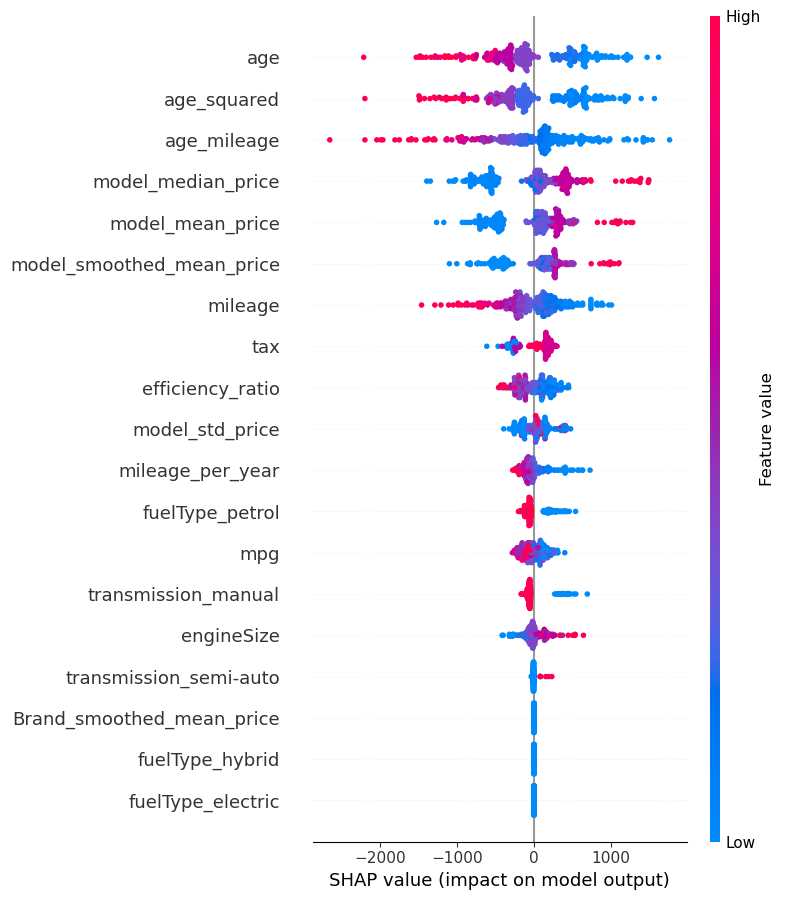

In [114]:
shap.initjs()

sample_opel = X_train_opel_final.sample(300, random_state=69)

explainer_opel = shap.TreeExplainer(rf_opel)
shap_values_opel = explainer_opel.shap_values(sample_opel)

shap.summary_plot(shap_values_opel, sample_opel)

### SHAP on Mercedes

In [115]:
X_train_mercedes = X_train_rfed[X_train_rfed['Brand'] == 'mercedes'].copy()
y_train_mercedes = y_train[X_train_rfed['Brand'] == 'mercedes'].copy()


scaler_mercedes = RobustScaler()
X_train_mercedes_num = pd.DataFrame(
    scaler_mercedes.fit_transform(X_train_mercedes[numeric_cols]),
    columns=numeric_cols,
    index=X_train_mercedes.index
)

In [116]:
X_train_mercedes_cat = pd.get_dummies(X_train_mercedes[categorical_cols], drop_first=True)
X_train_mercedes_final = pd.concat([X_train_mercedes_num, X_train_mercedes_cat], axis=1)


In [117]:
rf_mercedes = RandomForestRegressor(
    n_estimators=2000,
    max_depth=30,
    min_samples_split=3,
    min_samples_leaf=2,
    max_features=0.7,
    bootstrap= True,
    criterion= "squared_error",
    random_state=69,
    n_jobs=-1
)


rf_mercedes.fit(X_train_mercedes_final, y_train_mercedes)

,n_estimators,2000
,criterion,'squared_error'
,max_depth,30
,min_samples_split,3
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,0.7
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [118]:
X_val_mercedes = X_val_rfed[X_val_rfed['Brand'] == 'mercedes'].copy()
y_val_mercedes = y_val[X_val_rfed['Brand'] == 'mercedes'].copy()

X_val_mercedes_num = pd.DataFrame(
    scaler_mercedes.transform(X_val_mercedes[numeric_cols]),
    columns=numeric_cols,
    index=X_val_mercedes.index
)

X_val_mercedes_cat = pd.get_dummies(X_val_mercedes[categorical_cols], drop_first=True)

X_val_mercedes_cat = X_val_mercedes_cat.reindex(columns=X_train_mercedes_cat.columns, fill_value=0)

X_val_mercedes_final = pd.concat([X_val_mercedes_num, X_val_mercedes_cat], axis=1)

y_pred_mercedes = rf_mercedes.predict(X_val_mercedes_final)

c:\Users\liber\anaconda3\envs\ML_env\Lib\site-packages\shap\explainers\_tree.py:253: FutureWarning: In the future, passing feature_perturbation='interventional' without providing a background dataset will raise an error. Please provide a background dataset to continue using the interventional approach or set feature_perturbation='auto' to automatically switch approaches.
  warnings.warn(


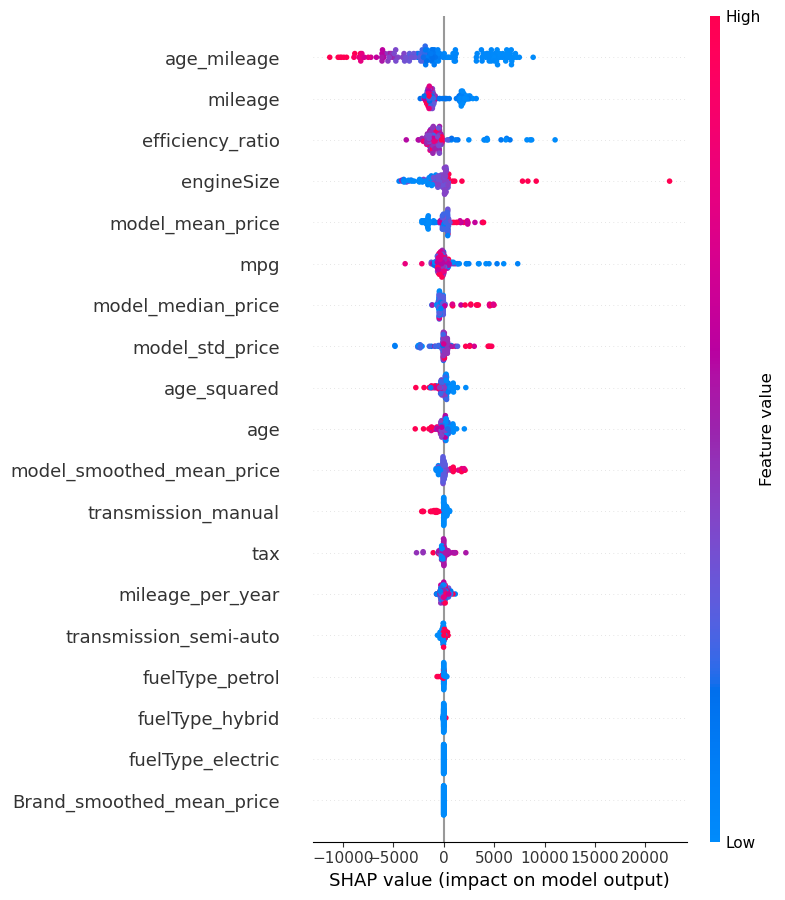

In [119]:
shap.initjs()

sample_mercedes = X_train_mercedes_final.sample(150, random_state=69)

explainer_mercedes = shap.TreeExplainer(
    rf_mercedes,
    feature_perturbation="interventional",
    model_output="raw"
)

shap_values_mercedes = explainer_mercedes.shap_values(
    sample_mercedes,
    approximate=True
)

shap.summary_plot(shap_values_mercedes, sample_mercedes)


## Lazy learners and pretrained models

compare xgboost
compare tabnet

In [120]:
from xgboost import XGBRegressor

In [121]:
XG = XGBRegressor(random_state=69)
XG_trainer = BrandModelTrainer(XG)


XG_trainer.fit(X_train_rfed, y_train)


XG_trainer.evaluate_train(X_train_rfed, y_train)
XG_trainer.evaluate(X_val_rfed, y_val)

XG_trainer.evaluate_train_by_brand(X_train_rfed, y_train)
XG_trainer.evaluate_by_brand(X_val_rfed, y_val)

Training models for 9 brands...

  ✓ opel done.
  ✓ audi done.
  ✓ mercedes done.
  ✓ ford done.
  ✓ bmw done.
  ✓ toyota done.
  ✓ hyundai done.
  ✓ vw done.
  ✓ skoda done.

Training Set Performance (Overall):
  RMSE: 1064.72
  MAE:  726.13
  R²:   0.9877

Validation Set Performance (Overall):
  RMSE: 1975.27
  MAE:  1226.57
  R²:   0.9570

Training Performance per Brand:
   Brand     N        RMSE         MAE       R²
 hyundai  2721  525.564347  359.891807 0.992318
  toyota  3775  536.624580  392.457774 0.992498
   skoda  3504  636.555807  467.222812 0.989191
    opel  7640  653.996315  476.042899 0.965833
    ford 13111  883.833428  648.901367 0.965489
      vw  8479 1028.873373  735.493279 0.982211
    audi  5970 1217.383241  887.038579 0.989135
     bmw  6037 1277.413740  904.534579 0.987342
mercedes  9541 1601.048757 1142.191185 0.977163

Validation Performance per Brand:
   Brand    N        RMSE         MAE       R²
    opel 1908 1178.472200  797.583610 0.890977
 hyundai  686 

,Brand,N,RMSE,MAE,R²
7,opel,1908,1178.472200,797.583610,0.890977
5,hyundai,686,1275.591252,899.999565,0.952514
8,skoda,882,1409.059456,1015.753893,0.947891
3,toyota,940,1411.602684,904.677858,0.955928
1,ford,3278,1425.026661,899.995898,0.910458
0,vw,2125,1756.415089,1175.035184,0.948935
6,audi,1490,2556.899499,1668.022915,0.948890
2,bmw,1505,2575.374175,1618.092294,0.948344
4,mercedes,2381,2821.926135,1841.464178,0.927250


## General model

compare general model on vs our divided one

In [122]:

numeric_cols = X_train_rfed.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'price'] 

categorical_cols = ['Brand', 'transmission', 'fuelType']

preprocessor = ColumnTransformer([
    ('num', RobustScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

rf_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('estimator', RandomForestRegressor(
        n_estimators=800,
        max_depth=20,
        min_samples_split=3,
        min_samples_leaf=2,
        max_features=0.4,
        min_impurity_decrease=0.01,
        max_samples=None,
        criterion="squared_error",
        bootstrap=True,
        random_state=69,
        n_jobs=-1
    ))
])


rf_pipeline.fit(X_train_rfed, y_train)


y_pred_val = rf_pipeline.predict(X_val_rfed)



rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
mae = mean_absolute_error(y_val, y_pred_val)
r2 = r2_score(y_val, y_pred_val)

print(f'RMSE: {rmse:.2f}, MAE: {mae:.2f}, R²: {r2:.4f}')


RMSE: 1985.84, MAE: 1227.06, R²: 0.9565
